In [11]:
import os
import pandas as pd
import numpy as np
import pyranges as pr
import gseapy as gp
import matplotlib.pyplot as plt
import pyreadr
from pathlib import Path
from gseapy import dotplot
import warnings
warnings.filterwarnings('ignore')

In [12]:
DMR_FILE      = 'data/LOY_ROY_corrected_bsseq_DMR0.2.rds'
GENE_SETS_DIR = 'data/Gene_sets_db'
GENE_ANNO_CSV = 'data/ensembl_gene_annotations.csv'
OUT_DIR       = Path('figures')

PROMOTER_UPSTREAM   = 5000
PROMOTER_DOWNSTREAM = 5000
MIN_GENE_SET_SIZE   = 10
MAX_GENE_SET_SIZE   = 500
PERMUTATION_NUM     = 1000
SEED                = 6
THREADS             = 4

In [13]:
# Load Hallmark gene sets only
def csv_to_dict(df):
    result = {}
    for _, row in df.iterrows():
        if pd.notna(row[0]) and str(row[0]).strip():
            result[row[0]] = list(row[2:].dropna().astype(str))
    return result

hall_dict = csv_to_dict(
    pd.read_csv(os.path.join(GENE_SETS_DIR, 'MSigDB_Hallmark_2020.csv'), delimiter=';', header=None)
)
print(f'Hallmark gene sets: {len(hall_dict)}')

Hallmark gene sets: 50


In [14]:
# Load DMRs
dmr_main = pyreadr.read_r(DMR_FILE)[None]
print(f'Loaded {len(dmr_main)} DMRs')

std_chrs = ['chr' + str(i) for i in range(1, 23)] + ['chrX']

dmr_df = pd.DataFrame({
    'Chromosome': dmr_main['chr'],
    'Start':      dmr_main['start'].astype(int),
    'End':        dmr_main['end'].astype(int),
    'diffMethy':  dmr_main['diff.Methy'],
    'areaStat':   dmr_main['areaStat'],
    'nCG':        dmr_main['nCG']
})
dmr_df = dmr_df[dmr_df['Chromosome'].isin(std_chrs)]
dmr_gr = pr.PyRanges(dmr_df)

Loaded 21250 DMRs


In [15]:
# Load saved gene annotations (skips slow BioMart query)
# Note: the CSV was saved before adding 'chr' prefix, so chromosomes are "1","2",... not "chr1","chr2",...
gene_anno = pd.read_csv(GENE_ANNO_CSV)

std_chrs_bare = [str(i) for i in range(1, 23)] + ['X']
gene_anno = gene_anno[gene_anno['chr'].isin(std_chrs_bare)].copy()

# Add 'chr' prefix to match DMR chromosome naming
gene_anno['chr'] = 'chr' + gene_anno['chr'].astype(str)
print(f'Gene annotations: {len(gene_anno)}')

# Define promoters (+/- 5kb from TSS)
gene_anno['tss']        = np.where(gene_anno['strand'] == 1, gene_anno['start'], gene_anno['end'])
gene_anno['prom_start'] = (gene_anno['tss'] - PROMOTER_UPSTREAM).clip(lower=0).astype(int)
gene_anno['prom_end']   = (gene_anno['tss'] + PROMOTER_DOWNSTREAM).astype(int)

promoter_gr = pr.PyRanges(pd.DataFrame({
    'Chromosome':   gene_anno['chr'],
    'Start':        gene_anno['prom_start'],
    'End':          gene_anno['prom_end'],
    'gene_name':    gene_anno['gene_name'],
    'gene_biotype': gene_anno['gene_biotype']
}))

Gene annotations: 77982


In [16]:
# Overlap DMRs with promoters and build ranked gene list
overlap_df = dmr_gr.join(promoter_gr).df
print(f'DMR-promoter overlaps: {len(overlap_df)}')

def get_max_extreme(x):
    return x[np.abs(x).idxmax()]

gene_rank = overlap_df.groupby('gene_name')['areaStat'].apply(get_max_extreme).reset_index()
gene_rank.columns = ['gene_name', 'signed_score']

# Flip signs: hypomethylated (negative areaStat) becomes positive NES
gene_rank['signed_score'] = -gene_rank['signed_score']
gene_rank = gene_rank.sort_values('signed_score', ascending=False)
glist_rnk = gene_rank.set_index('gene_name')

print(f'Ranked genes: {len(glist_rnk)}')
print(f'Score range: {glist_rnk["signed_score"].min():.2f} to {glist_rnk["signed_score"].max():.2f}')

DMR-promoter overlaps: 5143
Ranked genes: 1860
Score range: -598.44 to 1784.28


In [17]:
%%time
pre_res = gp.prerank(
    rnk=glist_rnk,
    gene_sets=hall_dict,
    threads=THREADS,
    min_size=MIN_GENE_SET_SIZE,
    max_size=MAX_GENE_SET_SIZE,
    permutation_num=PERMUTATION_NUM,
    outdir=str(OUT_DIR / 'gsea_hallmark_hypomethylated_positive'),
    seed=SEED,
    verbose=True
)
print('GSEA completed!')
pre_res.res2d.sort_values('FDR q-val').head(10)

2026-02-18 17:28:14,604 [WARNING] Duplicated values found in preranked stats: 15.59% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-02-18 17:28:14,606 [INFO] Parsing data files for GSEA.............................
2026-02-18 17:28:14,618 [INFO] 0040 gene_sets have been filtered out when max_size=500 and min_size=10
2026-02-18 17:28:14,619 [INFO] 0010 gene_sets used for further statistical testing.....
2026-02-18 17:28:14,620 [INFO] Start to run GSEA...Might take a while..................
2026-02-18 17:28:18,315 [INFO] Congratulations. GSEApy runs successfully................



GSEA completed!
CPU times: user 1.93 s, sys: 238 ms, total: 2.17 s
Wall time: 3.72 s


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
1,prerank,Hypoxia,0.809541,1.536133,0.020761,0.10594,0.16,3/12,0.97%,CAVIN3;LOX;IRS2
0,prerank,Estrogen Response Early,0.836711,1.543459,0.017647,0.192196,0.146,4/11,3.98%,KRT19;KRT15;MAPT;FOXC1
3,prerank,Epithelial Mesenchymal Transition,0.729157,1.395755,0.121387,0.253271,0.567,4/12,13.82%,LOX;THY1;CCN1;IGFBP2
2,prerank,Allograft Rejection,0.753542,1.401788,0.101896,0.319169,0.541,3/10,9.41%,ITGB2;THY1;ICOSLG
7,prerank,Apical Junction,0.669901,1.234091,0.292978,0.334317,0.884,7/10,27.96%,THY1;KCNH2;ICAM5;RHOF;LAMA3;FLNC;NLGN3
6,prerank,TNF-alpha Signaling via NF-kB,0.63994,1.2451,0.243604,0.364875,0.872,7/16,19.14%,IRS2;NR4A3;ICOSLG;CCN1;FOSL1;EGR3;BHLHE40
4,prerank,Glycolysis,0.683057,1.302962,0.183815,0.378141,0.794,3/12,7.10%,IRS2;HS6ST2;EFNA3
8,prerank,KRAS Signaling Up,0.601756,1.148757,0.365854,0.409093,0.946,4/12,17.26%,ITGB2;HOXD11;PCP4;ANO1
5,prerank,KRAS Signaling Dn,0.635874,1.248115,0.246667,0.419706,0.869,7/15,16.77%,KRT15;COL2A1;KCNQ2;CALCB;SHOX2;IGFBP2;MAGIX
9,prerank,UV Response Dn,0.575605,1.053402,0.469767,0.466018,0.983,4/10,19.14%,DDAH1;CCN1;HAS2;BHLHE40


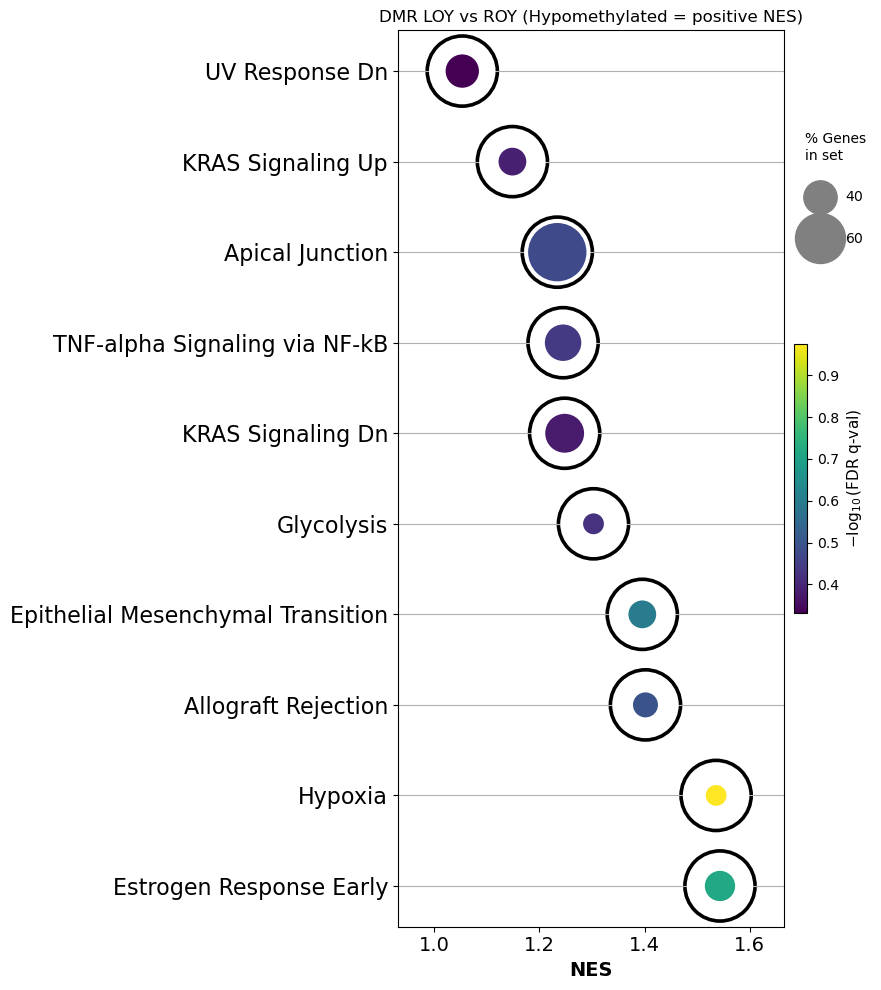

In [18]:
plt.style.use('default')

sorted_res = pre_res.res2d.sort_values('NES', ascending=False)

ax = dotplot(
    sorted_res,
    column='FDR q-val',
    cmap=plt.cm.viridis,
    size=10,
    top_term=10,
    figsize=(10, 10),
    show_ring=True,
    orderby='NES',
    cutoff=1.0
)

fig = ax.figure

# Fix colorbar to show -log10(FDR)
fdr_vals    = sorted_res['FDR q-val'].astype(float)
neg_log_fdr = -np.log10(fdr_vals)
vmin, vmax  = neg_log_fdr.min(), neg_log_fdr.max()

for collection in ax.collections:
    collection.set_clim(vmin, vmax)

for a in [a for a in fig.axes if a != ax]:
    a.remove()

sm   = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=vmin, vmax=vmax))
cbar = fig.colorbar(sm, ax=ax, shrink=0.3, aspect=20, pad=0.02)
cbar.set_label(r'$-\log_{10}$(FDR q-val)', fontsize=11)

ax.invert_yaxis()
ax.set_title('DMR LOY vs ROY (Hypomethylated = positive NES)', fontsize=12)
plt.tight_layout()

plt.savefig(OUT_DIR / 'DMR_LOY_vs_ROY_dotplot_hypomethylated_positive_NES_sorted.pdf',
            format='pdf', dpi=300, bbox_inches='tight')
plt.savefig(OUT_DIR / 'DMR_LOY_vs_ROY_dotplot_hypomethylated_positive_NES_sorted.png',
            dpi=300, bbox_inches='tight')
plt.show()